# Bank Customer Churn & Retention Analysis


## 1. Project Introduction
Banks rely heavily on maintaining long-term relationships with their customers. Customer churn occurs when customers stop using a bank's products or services, which can result in lost revenue and increased customer acquisition costs.

This project analyses customer demographic, financial, and behavioural data to understand customer churn and identify patterns associated with customers leaving the bank. The analysis will focus on identifying customer segments and behaviours associated with higher churn and generating insights that may help support customer retention strategies.

## 2. Business Problem
Customer churn can negatively affect a bank's profitability and long-term customer relationships. Understanding which customers are leaving and what characteristics or behaviours are associated with churn can help banks develop more effective customer retention strategies.

## 3. Project Objectives
1. Measure the overall customer churn rate.
2. Understand the demographic characteristics of the bank's customers.
3. Compare churn across different customer segments.
4. Analyse customer activity and transaction behaviour in relation to churn.
5. Examine financial characteristics such as credit limits, revolving balances, and credit utilisation.
6. Identify customer groups and behavioural patterns associated with higher churn.
7. Develop data-driven recommendations that may help the bank improve customer retention.

## 4. Business Questions
1. What percentage of customers have churned?
2. Which demographic groups have higher churn rates?
3. Does churn vary across income and card categories?
4. Is customer inactivity associated with higher churn?
5. How does transaction frequency differ between existing and churned customer?
6. How does transaction amount differ between existing and churned customers?
7. Is the number of products or relationships a customer has with the bank associated with churn?
8. Are customer who contact the bank more frequently more likely to churn?
9. How does credit utilisation differe between existing and churned customers?
10. What customer characteristics and behaviours appear to be the strongest indicators of churn?

## 5. Import Libraries and Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("BankChurners.csv")

Saving BankChurners.csv to BankChurners.csv


In [ ]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 6. Dataset Understanding

### 6.1 Dataset Shape


In [ ]:
df.shape

(10127, 23)

### 6.2 Column Names

In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

### 6.3 Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

### 6.4 Statistical Summary

In [ ]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


### 6.5 Categorical Summary

In [ ]:
df.describe(include="object")

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
count,10127,10127,10127,10127,10127,10127
unique,2,2,7,4,6,4
top,Existing Customer,F,Graduate,Married,Less than $40K,Blue
freq,8500,5358,3128,4687,3561,9436


## 7. Data Cleaning

### 7.1 Check Missing Values

In [ ]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


### 7.2 Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["CLIENTNUM"].duplicated().sum()

np.int64(0)

### 7.3 Check Categorical Values

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(column)
    print(df[column].value_counts())
    print()

Attrition_Flag
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Gender
Gender
F    5358
M    4769
Name: count, dtype: int64

Education_Level
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Marital_Status
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Income_Category
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Card_Category
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64



#### Comment
The categorical variables are generally consistent, with no obvious spelling or formatting issues. However, Unknown values are present in Education Level (1,519), Marital Status (749), and Income Category (1,112). These records will be retained because the remaining customer information is still useful for the analysis. Card Category is highly imbalanced, with Blue being the dominant card type.

### 7.4 Check Numerical Values

In [ ]:
numerical_columns = [
    "Customer_Age",
    "Dependent_count",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Avg_Utilization_Ratio"]

for column in numerical_columns:
    print(column, (df[column] < 0).sum())

Customer_Age 0
Dependent_count 0
Months_on_book 0
Total_Relationship_Count 0
Months_Inactive_12_mon 0
Contacts_Count_12_mon 0
Credit_Limit 0
Total_Revolving_Bal 0
Avg_Open_To_Buy 0
Total_Trans_Amt 0
Total_Trans_Ct 0
Avg_Utilization_Ratio 0


In [ ]:
print("Age:", df["Customer_Age"].min(), "-", df["Customer_Age"].max())

print("Inactive Months:", df["Months_Inactive_12_mon"].min(), "-", df["Months_Inactive_12_mon"].max())

print("Utilization Ratio:", df["Avg_Utilization_Ratio"].min(), "-", df["Avg_Utilization_Ratio"].max())

Age: 26 - 73
Inactive Months: 0 - 6
Utilization Ratio: 0.0 - 0.999


#### Comment
The selected numerical variables fall within logical ranges. Customer ages range from 26 to 73 years, inactivity ranges from 0 to 6 months, and the average utilization ratio ranges from 0 to 0.999. No obvious invalid numerical values were identified.

### 7.5 Remove Unnecessary Columns

In [ ]:
df = df.drop(columns=df.columns[-2:])
df.shape

(10127, 21)

#### Comment
The two Naive Bayes classifier columns were removed because they contain model-generated prediction information that is not required for the customer churn analysis. The dataset now contains 21 columns and 10,127 customer records.

In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

### 7.6 Outlier Investigation

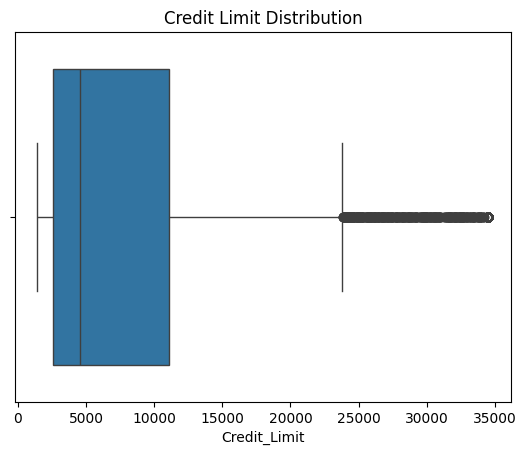

In [ ]:
sns.boxplot(x=df["Credit_Limit"])
plt.title("Credit Limit Distribution")
plt.show()

In [ ]:
Q1 = df["Credit_Limit"].quantile(0.25)
Q3 = df["Credit_Limit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 2555.0
Q3: 11067.5
IQR: 8512.5
Lower Bound: -10213.75
Upper Bound: 23836.25


In [ ]:
credit_limit_outliers = df[
    (df["Credit_Limit"] < lower_bound) |
    (df["Credit_Limit"] > upper_bound)
]

credit_limit_outliers.shape[0]

984

#### Comment
Using the IQR method, 984 Credit Limit observations were identified as statistical outliers above the upper bound of \$23,836.25. However, these values fall within a plausible credit limit range and may represent genuine high-credit customers. Therefore, these observations were retained for the analysis.

In [ ]:
# Outlier Summary for Numerical Variables

outlier_columns = [
    "Customer_Age",
    "Months_on_book",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Avg_Utilization_Ratio"]

In [ ]:


for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)]

    print(column, ":", outliers.shape[0])

Customer_Age : 2
Months_on_book : 386
Credit_Limit : 984
Total_Revolving_Bal : 0
Avg_Open_To_Buy : 963
Total_Trans_Amt : 896
Total_Trans_Ct : 2
Avg_Utilization_Ratio : 0


#### Comment
The IQR method identified statistical outliers in several numerical variables, particularly Credit Limit, Average Open to Buy, and Total Transaction Amount. However, the observed values remain within plausible business ranges and may represent genuine customer behaviour rather than data errors. Therefore, the outliers were retained to avoid removing potentially valuable customer information.

### 7.7 Final Data Validation

In [ ]:
print("Dataset Shape:", df.shape)

print("Missing Values:", df.isnull().sum().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("Duplicate Customer IDs:", df["CLIENTNUM"].duplicated().sum())

Dataset Shape: (10127, 21)
Missing Values: 0
Duplicate Rows: 0
Duplicate Customer IDs: 0


#### Comment
Following data cleaning and validation, the dataset contains 10,127 unique customer records and 21 columns. No null values or duplicate records were found. Unnecessary model-generated columns were removed, while valid statistical outliers and Unknown categorical values were retained for analysis.

## 8. Exploratory Data Analysis (EDA)

### 8.1 Customer Churn Overview

In [ ]:
df["Attrition_Flag"].value_counts()

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [ ]:
df["Attrition_Flag"].value_counts(normalize=True) * 100

,proportion
Attrition_Flag,
Existing Customer,83.934038
Attrited Customer,16.065962


#### Comment
Of the 10,127 customers, 8,500 (83.93%) are existing customers and 1,627 (16.07%) are attrited customers. Therefore, the overall customer churn rate is approximately 16.07%.

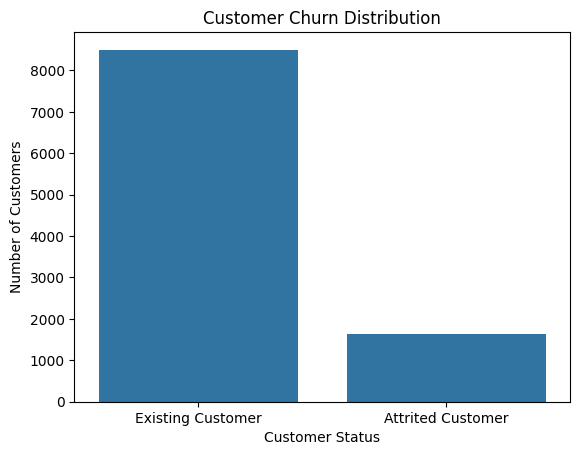

In [ ]:
## Visualize Customer Churn
sns.countplot(data=df, x="Attrition_Flag")

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

### 8.2 Customer Demographics

#### 8.2.1 Age Distribution

In [ ]:
df["Customer_Age"].describe()

,Customer_Age
count,10127.000000
mean,46.325960
std,8.016814
min,26.000000
25%,41.000000
50%,46.000000
75%,52.000000
max,73.000000


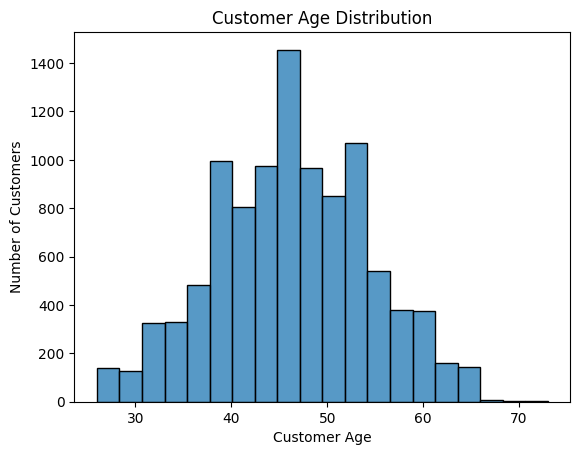

In [ ]:
sns.histplot(data=df, x="Customer_Age", bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()

#### Comment
Customer ages range from 26 to 73 years, with an average age of approximately 46 years. The distribution is concentrated around middle-aged customers, particularly those in their 40s and early 50s, with fewer customers at the younger and older ends of the age range.

In [ ]:
df.groupby("Attrition_Flag")["Customer_Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
Attrited Customer,1627.0,46.659496,7.665652,26.0,41.0,47.0,52.0,68.0
Existing Customer,8500.0,46.262118,8.081157,26.0,41.0,46.0,52.0,73.0


#### Comment
Attrited customers have an average age of 46.66 years compared with 46.26 years for existing customers. The median ages are also similar at 47 and 46 years respectively, while both groups share the same interquartile range of 41–52 years. This suggests that overall age distributions are relatively similar between existing and attrited customers.

In [ ]:
# Age_Group(new column)

bins = [25, 35, 45, 55, 65, 75]

labels = ["26-35", "36-45", "46-55", "56-65", "66+"]

df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=bins,
    labels=labels)

In [ ]:
df[["Customer_Age", "Age_Group"]].head(10)

,Customer_Age,Age_Group
0,45,36-45
1,49,46-55
2,51,46-55
3,40,36-45
4,40,36-45
5,44,36-45
6,51,46-55
7,32,26-35
8,37,36-45
9,48,46-55


In [ ]:
df["Age_Group"].value_counts().sort_index()

,count
Age_Group,
26-35,919
36-45,3742
46-55,4135
56-65,1321
66+,10


In [ ]:
# Churn Rate by Age Group

age_churn = pd.crosstab(
    df["Age_Group"],
    df["Attrition_Flag"],
    normalize="index") * 100

age_churn

Attrition_Flag,Attrited Customer,Existing Customer
Age_Group,,
26-35,13.275299,86.724701
36-45,16.194548,83.805452
46-55,16.638452,83.361548
56-65,15.821347,84.178653
66+,20.000000,80.000000


#### Comment
Churn rates are relatively similar across the major age groups. Customers aged 46–55 have the highest churn rate among the well-represented groups at approximately 16.64%, while customers aged 26–35 have the lowest at approximately 13.28%. Although the 66+ group shows a 20% churn rate, it contains only 10 customers and should therefore be interpreted cautiously. Overall, age does not appear to strongly differentiate customer churn.

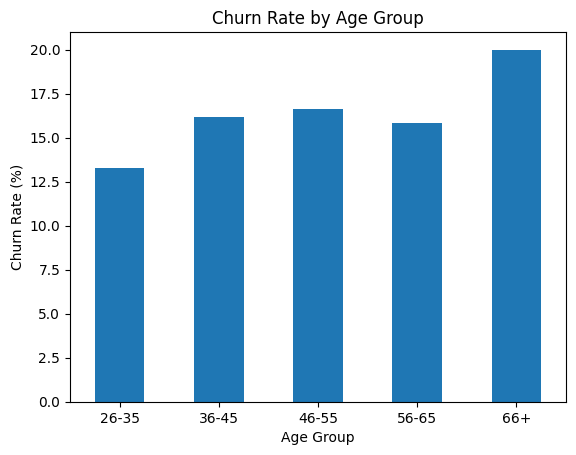

In [ ]:
age_churn_rate = age_churn["Attrited Customer"]

age_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.2.2 Gender vs Churn

In [ ]:
# Gender distribution - count and percentage

print("Gender Count:")
print(df["Gender"].value_counts())

print()

print("Gender Percentage:")
print(df["Gender"].value_counts(normalize=True) * 100)

Gender Count:
Gender
F    5358
M    4769
Name: count, dtype: int64

Gender Percentage:
Gender
F    52.908068
M    47.091932
Name: proportion, dtype: float64


#### Comment
Female customers represent approximately 52.91% of the dataset, while male customers represent 47.09%, indicating a relatively balanced gender distribution.

In [ ]:
# churn rate within each gender

gender_churn = pd.crosstab(
    df["Gender"],
    df["Attrition_Flag"],
    normalize="index") * 100

print (gender_churn)

Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                       17.357223          82.642777
M                       14.615223          85.384777


#### Comment
Female customers have a higher churn rate (17.36%) than male customers (14.62%), a difference of approximately 2.74 percentage points. This suggests that gender is associated with some variation in customer churn, although further behavioural and financial analysis is needed to understand the underlying factors.

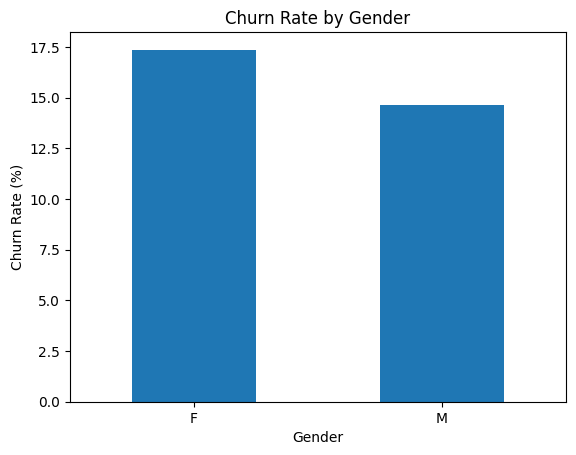

In [ ]:
gender_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.2.3 Education Level vs Churn

In [ ]:
# Education level distribution - count and percentage

print("Education Level Count:")
print(df["Education_Level"].value_counts())

print()

print("Education Level Percentage:")
print(df["Education_Level"].value_counts(normalize=True) * 100)

Education Level Count:
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Education Level Percentage:
Education_Level
Graduate         30.887726
High School      19.877555
Unknown          14.999506
Uneducated       14.683519
College          10.002962
Post-Graduate     5.095290
Doctorate         4.453441
Name: proportion, dtype: float64


#### Comment
Graduates represent the largest education group at approximately 30.89% of customers, followed by High School at 19.88%. Education information is unknown for approximately 15% of customers.

In [ ]:
# Churn rate within each education level

education_churn = pd.crosstab(
    df["Education_Level"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(education_churn)

Attrition_Flag   Attrited Customer  Existing Customer
Education_Level                                      
College                  15.202369          84.797631
Doctorate                21.064302          78.935698
Graduate                 15.569054          84.430946
High School              15.201192          84.798808
Post-Graduate            17.829457          82.170543
Uneducated               15.938130          84.061870
Unknown                  16.853193          83.146807


#### Comment
Churn rates vary moderately across education levels. Doctorate customers have the highest churn rate at approximately 21.06%, followed by Post-Graduate customers at 17.83%. Most other education groups have churn rates between 15% and 17%, suggesting that education level alone may not be a strong churn driver.

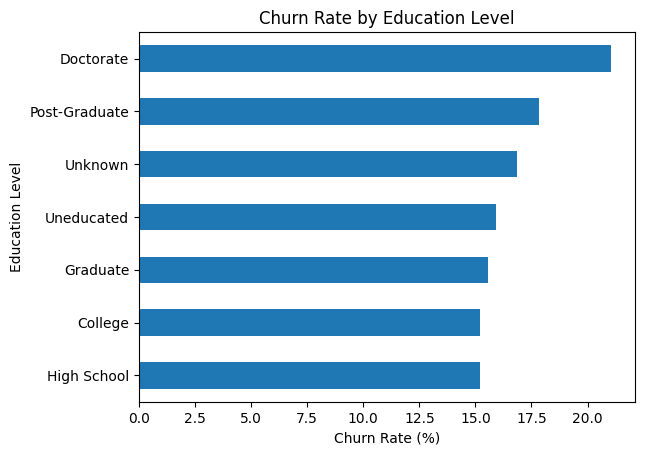

In [ ]:
education_churn["Attrited Customer"].sort_values().plot(kind="barh")

plt.title("Churn Rate by Education Level")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Education Level")

plt.show()

#### 8.2.4 Marital Status vs Churn

In [ ]:
# Marital status distribution - count and percentage

print("Marital Status Count:")
print(df["Marital_Status"].value_counts())

print()

print("Marital Status Percentage:")
print(df["Marital_Status"].value_counts(normalize=True) * 100)

Marital Status Count:
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Marital Status Percentage:
Marital_Status
Married     46.282216
Single      38.935519
Unknown      7.396070
Divorced     7.386195
Name: proportion, dtype: float64


#### Comment

Married customers represent the largest group at approximately 46.28%, followed by single customers at 38.94%. Divorced customers and customers with unknown marital status each account for approximately 7.4% of the dataset.

In [ ]:
# Churn rate within each marital status

marital_churn = pd.crosstab(
    df["Marital_Status"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(marital_churn)

Attrition_Flag  Attrited Customer  Existing Customer
Marital_Status                                      
Divorced                16.176471          83.823529
Married                 15.126947          84.873053
Single                  16.941415          83.058585
Unknown                 17.222964          82.777036


#### Comment

Churn rates are relatively similar across marital status groups. Customers with unknown marital status have the highest churn rate at approximately 17.22%, followed closely by single customers at 16.94%, while married customers have the lowest churn rate at 15.13%. Overall, marital status does not appear to be a strong differentiator of customer churn.


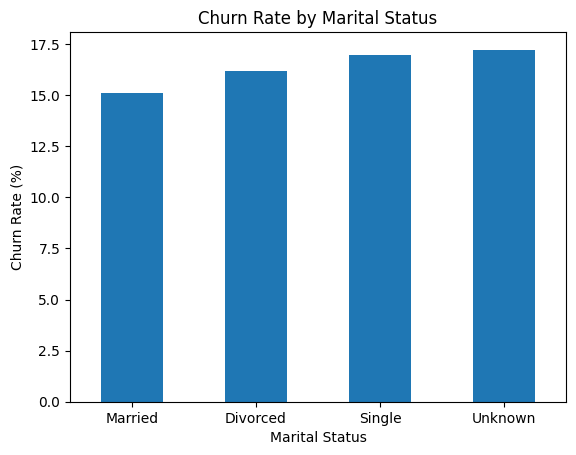

In [ ]:
marital_churn["Attrited Customer"].sort_values().plot(kind="bar")

plt.title("Churn Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.2.5 Income Category vs Churn

In [ ]:
# Income category distribution - count and percentage

print("Income Category Count:")
print(df["Income_Category"].value_counts())

print()

print("Income Category Percentage:")
print(df["Income_Category"].value_counts(normalize=True) * 100)

Income Category Count:
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Income Category Percentage:
Income_Category
Less than $40K    35.163425
$40K - $60K       17.675521
$80K - $120K      15.157500
$60K - $80K       13.844179
Unknown           10.980547
$120K +            7.178829
Name: proportion, dtype: float64


#### Comment

Customers earning less than \$40K represent the largest income group at approximately 35.16% of the dataset. Customers earning \$120K or more represent the smallest known income group at approximately 7.18%, while income information is unknown for approximately 10.98% of customers.

In [ ]:
# Churn rate within each income category

income_churn = pd.crosstab(
    df["Income_Category"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(income_churn)

Attrition_Flag   Attrited Customer  Existing Customer
Income_Category                                      
$120K +                  17.331499          82.668501
$40K - $60K              15.139665          84.860335
$60K - $80K              13.480742          86.519258
$80K - $120K             15.765472          84.234528
Less than $40K           17.186184          82.813816
Unknown                  16.816547          83.183453


#### Comment

Churn rates vary moderately across income categories. Customers earning \$120K or more have the highest churn rate at approximately 17.33%, closely followed by customers earning less than \$40K at 17.19%. Customers earning \$60K–\$80K have the lowest churn rate at approximately 13.48%. There is no clear increasing or decreasing churn pattern across income levels, suggesting that income alone may not be a strong churn driver.

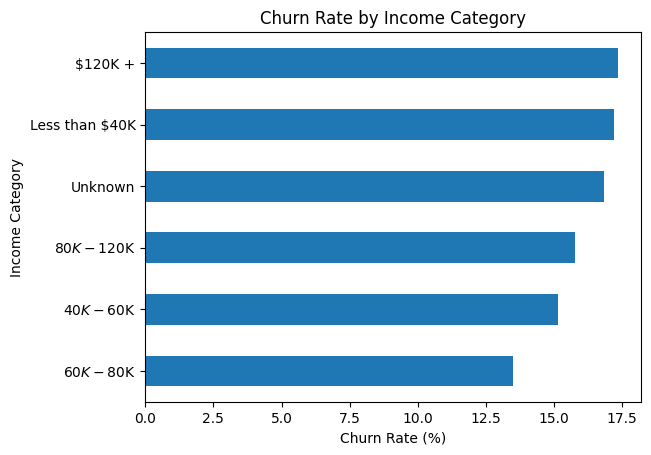

In [ ]:
income_churn["Attrited Customer"].sort_values().plot(kind="barh")

plt.title("Churn Rate by Income Category")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Income Category")

plt.show()

### 8.3 Card & Banking Relationship

#### 8.3.1 Card Category vs Churn

In [ ]:
# Card category distribution - count and percentage

print("Card Category Count:")
print(df["Card_Category"].value_counts())

print()

print("Card Category Percentage:")
print(df["Card_Category"].value_counts(normalize=True) * 100)

Card Category Count:
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64

Card Category Percentage:
Card_Category
Blue        93.176656
Silver       5.480399
Gold         1.145453
Platinum     0.197492
Name: proportion, dtype: float64


#### Comment

Blue card customers dominate the dataset, representing approximately 93.18% of all customers. Silver, Gold, and Platinum customers represent much smaller proportions, with Platinum accounting for only 0.20%. Therefore, churn rates for the smaller card categories, particularly Platinum, should be interpreted cautiously due to their small sample sizes.

In [ ]:
# Churn rate within each card category

card_churn = pd.crosstab(
    df["Card_Category"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(card_churn)

Attrition_Flag  Attrited Customer  Existing Customer
Card_Category                                       
Blue                    16.097923          83.902077
Gold                    18.103448          81.896552
Platinum                25.000000          75.000000
Silver                  14.774775          85.225225


#### Comment

Platinum card customers show the highest churn rate at 25%, followed by Gold customers at approximately 18.10%. However, Platinum and Gold contain only 20 and 116 customers respectively, so these rates should be interpreted cautiously. Blue customers, who represent the vast majority of the dataset, have a churn rate of approximately 16.10%. Overall, the results do not provide strong evidence that card category alone is a major churn driver.

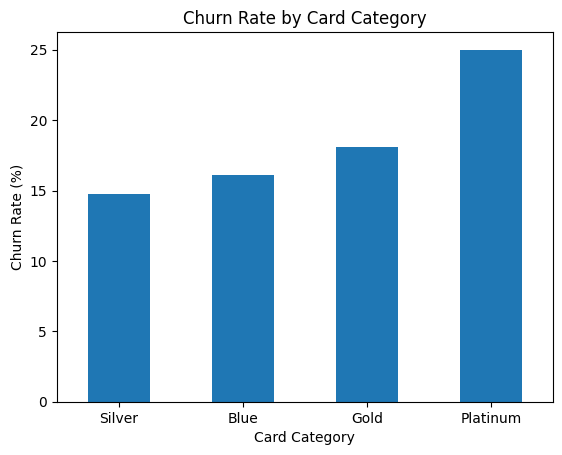

In [ ]:
card_churn["Attrited Customer"].sort_values().plot(kind="bar")

plt.title("Churn Rate by Card Category")
plt.xlabel("Card Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.3.2 Months on Book vs Churn

In [ ]:
# Months on book statistics by customer status

months_churn = df.groupby("Attrition_Flag")["Months_on_book"].describe()

print(months_churn)

                    count       mean       std   min   25%   50%   75%   max
Attrition_Flag                                                              
Attrited Customer  1627.0  36.178242  7.796548  13.0  32.0  36.0  40.0  56.0
Existing Customer  8500.0  35.880588  8.021810  13.0  31.0  36.0  40.0  56.0


#### Comment

Attrited customers have been with the bank for an average of approximately 36.18 months, compared with 35.88 months for existing customers. Both groups have the same median relationship length of 36 months. The very small difference suggests that Months on Book alone does not appear to be a strong differentiator of customer churn.

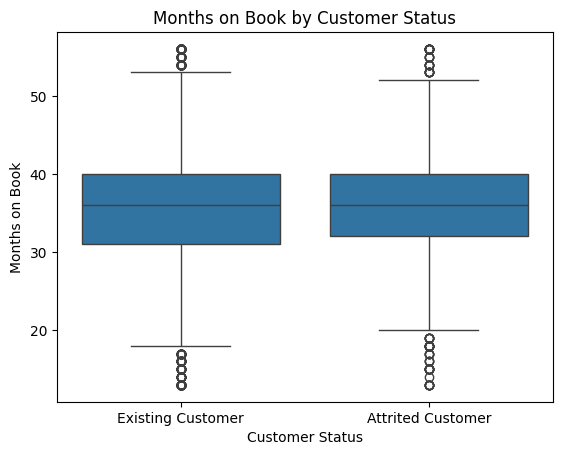

In [ ]:
sns.boxplot(
    data=df,
    x="Attrition_Flag",
    y="Months_on_book")

plt.title("Months on Book by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Months on Book")

plt.show()

#### 8.3.3 Total Relationship Count vs Churn

In [ ]:
# Total relationship count distribution - count and percentage

print("Relationship Count:")
print(df["Total_Relationship_Count"].value_counts().sort_index())

print()

print("Relationship Count Percentage:")
print(df["Total_Relationship_Count"].value_counts(normalize=True).sort_index() * 100)

Relationship Count:
Total_Relationship_Count
1     910
2    1243
3    2305
4    1912
5    1891
6    1866
Name: count, dtype: int64

Relationship Count Percentage:
Total_Relationship_Count
1     8.985879
2    12.274119
3    22.760936
4    18.880221
5    18.672855
6    18.425990
Name: proportion, dtype: float64


#### Comment

Customers with 3 banking relationships represent the largest group at approximately 22.76% of the dataset. Customers with only 1 relationship represent the smallest group at approximately 8.99%. Overall, customers are distributed across all six relationship-count categories.

In [ ]:
# Churn rate within each relationship count

relationship_churn = pd.crosstab(
    df["Total_Relationship_Count"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(relationship_churn)

Attrition_Flag            Attrited Customer  Existing Customer
Total_Relationship_Count                                      
1                                 25.604396          74.395604
2                                 27.835881          72.164119
3                                 17.353579          82.646421
4                                 11.767782          88.232218
5                                 12.004231          87.995769
6                                 10.503751          89.496249


#### Comment

Customers with fewer banking relationships show substantially higher churn rates. Customers with 2 relationships have the highest churn rate at approximately 27.84%, followed by customers with 1 relationship at 25.60%. Churn falls considerably among customers with 4–6 relationships, reaching its lowest level of approximately 10.50% for customers with 6 relationships. This suggests that customers with deeper relationships with the bank tend to have lower churn.

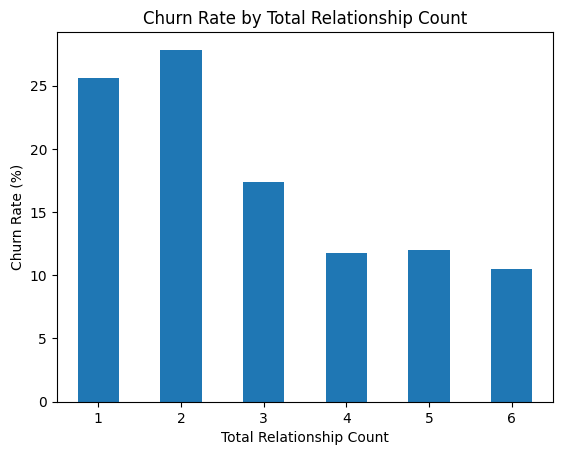

In [ ]:
# Churn rate by total relationship count

relationship_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Total Relationship Count")
plt.xlabel("Total Relationship Count")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### 8.4 Customer Activity & Churn

#### 8.4.1 Months Inactive vs Churn

In [ ]:
# Months inactive distribution - count and percentage

print("Months Inactive Count:")
print(df["Months_Inactive_12_mon"].value_counts().sort_index())

print()

print("Months Inactive Percentage:")
print(df["Months_Inactive_12_mon"].value_counts(normalize=True).sort_index() * 100)

Months Inactive Count:
Months_Inactive_12_mon
0      29
1    2233
2    3282
3    3846
4     435
5     178
6     124
Name: count, dtype: int64

Months Inactive Percentage:
Months_Inactive_12_mon
0     0.286363
1    22.049965
2    32.408413
3    37.977683
4     4.295448
5     1.757677
6     1.224449
Name: proportion, dtype: float64


#### Comment

Most customers were inactive for 2 or 3 months during the previous 12 months, representing approximately 32.41% and 37.98% of customers respectively. Very few customers recorded either 0 or 6 months of inactivity.

In [ ]:
# Churn rate within each inactivity level

inactive_churn = pd.crosstab(
    df["Months_Inactive_12_mon"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(inactive_churn)

Attrition_Flag          Attrited Customer  Existing Customer
Months_Inactive_12_mon                                      
0                               51.724138          48.275862
1                                4.478280          95.521720
2                               15.386959          84.613041
3                               21.476859          78.523141
4                               29.885057          70.114943
5                               17.977528          82.022472
6                               15.322581          84.677419


#### Comment

Churn generally increases as inactivity rises from 1 to 4 months, increasing from approximately 4.48% for customers inactive for 1 month to 29.89% for customers inactive for 4 months. This suggests that increasing customer inactivity may be an important churn warning indicator. However, the pattern does not continue for 5 and 6 months. Customers with 0 inactive months show an unusually high churn rate of 51.72%, but this group contains only 29 customers, so this result should be interpreted cautiously.

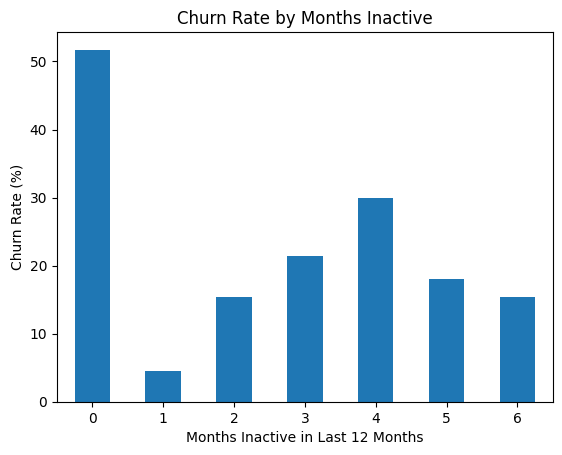

In [ ]:
# Churn rate by months inactive

inactive_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Months Inactive")
plt.xlabel("Months Inactive in Last 12 Months")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.4.2 Contacts with Bank vs Churn

In [ ]:
# Contact count distribution - count and percentage

print("Contact Count:")
print(df["Contacts_Count_12_mon"].value_counts().sort_index())

print()

print("Contact Count Percentage:")
print(df["Contacts_Count_12_mon"].value_counts(normalize=True).sort_index() * 100)

Contact Count:
Contacts_Count_12_mon
0     399
1    1499
2    3227
3    3380
4    1392
5     176
6      54
Name: count, dtype: int64

Contact Count Percentage:
Contacts_Count_12_mon
0     3.939962
1    14.802014
2    31.865311
3    33.376123
4    13.745433
5     1.737928
6     0.533228
Name: proportion, dtype: float64


#### Comment

Most customers contacted the bank 2 or 3 times during the last 12 months, representing approximately 31.87% and 33.38% of customers respectively. Customers with 5 or 6 contacts represent only a small proportion of the dataset.

In [ ]:
# Churn rate within each contact count

contact_churn = pd.crosstab(
    df["Contacts_Count_12_mon"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(contact_churn)

Attrition_Flag         Attrited Customer  Existing Customer
Contacts_Count_12_mon                                      
0                               1.754386          98.245614
1                               7.204803          92.795197
2                              12.488379          87.511621
3                              20.147929          79.852071
4                              22.629310          77.370690
5                              33.522727          66.477273
6                             100.000000           0.000000


#### Comment

Churn increases substantially as the number of customer contacts with the bank rises. The churn rate increases from approximately 1.75% for customers with no contacts to 33.52% for customers with 5 contacts. Customers with 6 contacts show a 100% churn rate, although this group contains only 54 customers and should be interpreted cautiously. Overall, frequent customer contact appears to be strongly associated with higher churn and may represent an important churn warning indicator.

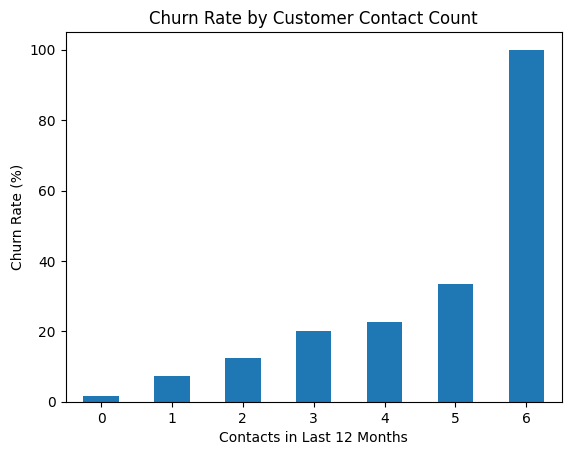

In [ ]:
# Churn rate by contact count

contact_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Customer Contact Count")
plt.xlabel("Contacts in Last 12 Months")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.4.3 Total Transaction Count vs Churn

In [ ]:
# Transaction count statistics by customer status

transaction_count_churn = df.groupby("Attrition_Flag")["Total_Trans_Ct"].describe()

print(transaction_count_churn)

                    count       mean        std   min   25%   50%   75%    max
Attrition_Flag                                                                
Attrited Customer  1627.0  44.933620  14.568429  10.0  37.0  43.0  51.0   94.0
Existing Customer  8500.0  68.672588  22.919011  11.0  54.0  71.0  82.0  139.0


#### Comment

Attrited customers show substantially lower transaction activity than existing customers. Attrited customers made an average of approximately 44.93 transactions compared with 68.67 for existing customers, while their median transaction counts were 43 and 71 respectively. This suggests that lower transaction activity is strongly associated with customer churn and may be an important churn indicator.

In [ ]:
# Create transaction count groups

bins = [0, 30, 50, 70, 90, 110, 140]

labels = ["0-30", "31-50", "51-70", "71-90", "91-110", "111-140"]

df["Transaction_Count_Group"] = pd.cut(
    df["Total_Trans_Ct"],
    bins=bins,
    labels=labels)

df["Transaction_Count_Group"].value_counts().sort_index()

,count
Transaction_Count_Group,
0-30,698
31-50,2430
51-70,2560
71-90,3323
91-110,729
111-140,387


#### Comment

The largest group consists of customers making 71–90 transactions, with 3,323 customers. Most customers fall between 31 and 90 transactions, while relatively fewer customers are found at the lowest and highest transaction levels.

In [ ]:
# Churn rate within each transaction count group

transaction_count_group_churn = pd.crosstab(
    df["Transaction_Count_Group"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(transaction_count_group_churn)

Attrition_Flag           Attrited Customer  Existing Customer
Transaction_Count_Group                                      
0-30                             29.226361          70.773639
31-50                            40.452675          59.547325
51-70                            12.851562          87.148438
71-90                             3.280169          96.719831
91-110                            0.274348          99.725652
111-140                           0.000000         100.000000


#### Comment

Customers with lower transaction activity show substantially higher churn rates. Customers making 31–50 transactions have the highest churn rate at approximately 40.45%, followed by customers making 0–30 transactions at 29.23%. Churn falls sharply as transaction activity increases, reaching approximately 3.28% for customers making 71–90 transactions and less than 1% for customers making more than 90 transactions. This suggests that low transaction activity is strongly associated with customer churn and may be an important churn indicator.

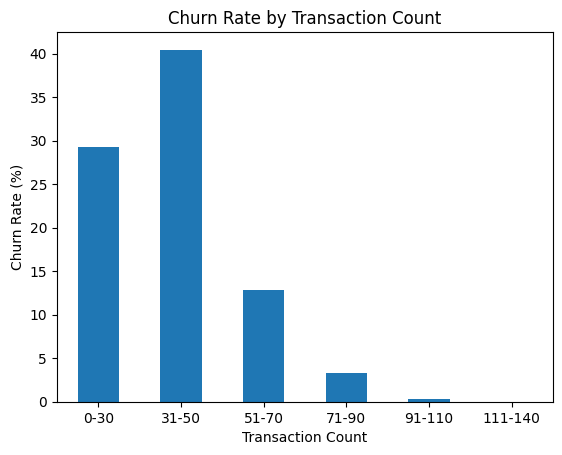

In [ ]:
# Churn rate by transaction count group

transaction_count_group_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#### 8.4.4 Total Transaction Amount vs Churn

In [ ]:
# Transaction amount statistics by customer status

transaction_amount_churn = df.groupby("Attrition_Flag")["Total_Trans_Amt"].describe()

print(transaction_amount_churn)

                    count         mean          std    min      25%     50%  \
Attrition_Flag                                                                
Attrited Customer  1627.0  3095.025814  2308.227629  510.0  1903.50  2329.0   
Existing Customer  8500.0  4654.655882  3512.772635  816.0  2384.75  4100.0   

                       75%      max  
Attrition_Flag                       
Attrited Customer  2772.00  10583.0  
Existing Customer  4781.25  18484.0  


#### Comment

Attrited customers have substantially lower transaction amounts than existing customers. Attrited customers have an average total transaction amount of approximately 3,095 compared with 4,655 for existing customers, while their median transaction amounts are 2,329 and 4,100 respectively. This suggests that lower transaction value is associated with customer churn and may be another important indicator of declining customer engagement.

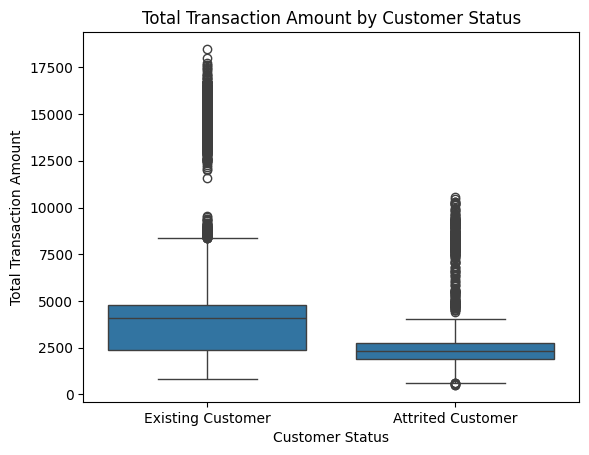

In [ ]:
# Total transaction amount by customer status

sns.boxplot(
    data=df,
    x="Attrition_Flag",
    y="Total_Trans_Amt")

plt.title("Total Transaction Amount by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Total Transaction Amount")

plt.show()

In [ ]:
# Create transaction amount groups

bins = [0, 2000, 4000, 6000, 8000, 10000, 19000]

labels = ["0-2000", "2001-4000", "4001-6000",
          "6001-8000", "8001-10000", "10001+"]

df["Transaction_Amount_Group"] = pd.cut(
    df["Total_Trans_Amt"],
    bins=bins,
    labels=labels)

# Check transaction amount groups

df["Transaction_Amount_Group"].value_counts().sort_index()

,count
Transaction_Amount_Group,
0-2000,2208
2001-4000,3080
4001-6000,3389
6001-8000,362
8001-10000,331
10001+,757


#### Comment

Most customers have total transaction amounts below 6,000, with the largest group being 4,001–6,000 at 3,389 customers. Higher transaction amount groups contain relatively fewer customers.

In [ ]:
# Churn rate within each transaction amount group

transaction_amount_group_churn = pd.crosstab(
    df["Transaction_Amount_Group"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(transaction_amount_group_churn)

Attrition_Flag            Attrited Customer  Existing Customer
Transaction_Amount_Group                                      
0-2000                            21.376812          78.623188
2001-4000                         27.467532          72.532468
4001-6000                          2.478607          97.521393
6001-8000                         19.889503          80.110497
8001-10000                        43.202417          56.797583
10001+                             1.321004          98.678996


#### Comment

Attrited customers generally have lower overall transaction amounts than existing customers, but churn does not follow a consistent pattern across transaction amount groups. The highest churn rate occurs among customers with transaction amounts of 8,001–10,000 at approximately 43.20%, while customers in the 4,001–6,000 and 10,001+ groups show much lower churn rates. This suggests that total transaction amount is associated with churn, but the relationship is non-linear and should not be interpreted as simply lower transaction amounts leading to higher churn.

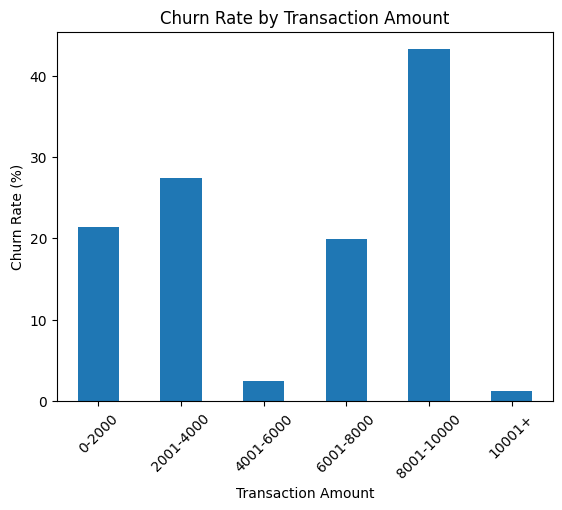

In [ ]:
# Churn rate by transaction amount group

transaction_amount_group_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

### 8.5 Credit Usage & Churn

#### 8.5.1 Credit Limit vs Churn

In [ ]:
# Credit limit statistics by customer status

credit_limit_churn = df.groupby("Attrition_Flag")["Credit_Limit"].describe()

print(credit_limit_churn)

                    count         mean          std     min     25%     50%  \
Attrition_Flag                                                                
Attrited Customer  1627.0  8136.039459  9095.334105  1438.3  2114.0  4178.0   
Existing Customer  8500.0  8726.877518  9084.969807  1438.3  2602.0  4643.5   

                        75%      max  
Attrition_Flag                        
Attrited Customer   9933.50  34516.0  
Existing Customer  11252.75  34516.0  


#### Comment

Attrited customers have a slightly lower average credit limit of approximately 8,136 compared with 8,727 for existing customers. Their median credit limits are also relatively similar at 4,178 and 4,644 respectively. Although attrited customers generally have somewhat lower credit limits, the difference is modest, suggesting that credit limit alone may not be a strong churn differentiator.

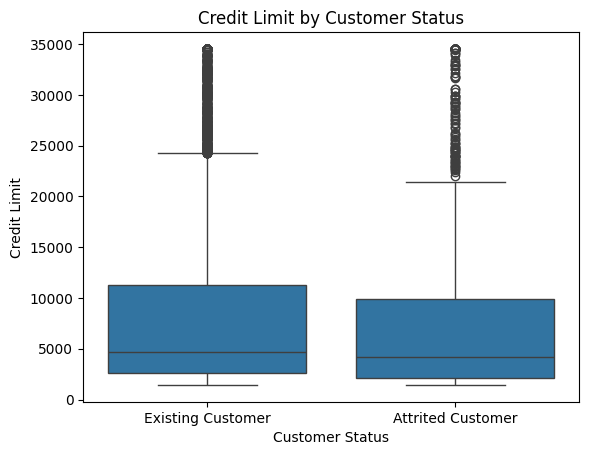

In [ ]:
# Credit limit by customer status

sns.boxplot(
    data=df,
    x="Attrition_Flag",
    y="Credit_Limit")

plt.title("Credit Limit by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Credit Limit")

plt.show()

#### 8.5.2 Average Utilization Ratio vs Churn

In [ ]:
# Average utilization ratio statistics by customer status

utilization_churn = df.groupby("Attrition_Flag")["Avg_Utilization_Ratio"].describe()

print(utilization_churn)

                    count      mean       std  min    25%    50%      75%  \
Attrition_Flag                                                              
Attrited Customer  1627.0  0.162475  0.264458  0.0  0.000  0.000  0.23100   
Existing Customer  8500.0  0.296412  0.272568  0.0  0.055  0.211  0.52925   

                     max  
Attrition_Flag            
Attrited Customer  0.999  
Existing Customer  0.994  


#### Comment

Attrited customers have a considerably lower average utilization ratio of approximately 16.2%, compared with 29.6% for existing customers. The median utilization ratio for attrited customers is 0%, compared with approximately 21.1% for existing customers. This suggests that lower credit utilization is associated with customer churn and may indicate lower engagement with the bank's credit products.

In [ ]:
# Create utilization ratio groups

bins = [-0.01, 0, 0.2, 0.4, 0.6, 0.8, 1.0]

labels = ["0", "0.01-0.20", "0.21-0.40",
          "0.41-0.60", "0.61-0.80", "0.81-1.00"]

df["Utilization_Group"] = pd.cut(
    df["Avg_Utilization_Ratio"],
    bins=bins,
    labels=labels)



df["Utilization_Group"].value_counts().sort_index()

,count
Utilization_Group,
0,2470
0.01-0.20,2876
0.21-0.40,1565
0.41-0.60,1414
0.61-0.80,1335
0.81-1.00,467


#### Comment

The largest group consists of customers with a utilization ratio between 0.01 and 0.20, with 2,876 customers. Additionally, 2,470 customers have a utilization ratio of exactly zero. Higher utilization groups contain progressively fewer customers, with only 467 customers having a utilization ratio above 0.80.

In [ ]:
# Churn rate within each utilization group

utilization_group_churn = pd.crosstab(
    df["Utilization_Group"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(utilization_group_churn)

Attrition_Flag     Attrited Customer  Existing Customer
Utilization_Group                                      
0                          36.153846          63.846154
0.01-0.20                  10.326843          89.673157
0.21-0.40                  10.095847          89.904153
0.41-0.60                   6.930693          93.069307
0.61-0.80                   6.441948          93.558052
0.81-1.00                  20.342612          79.657388


#### Comment

Customers with zero credit utilization have a substantially higher churn rate of approximately 36.15%. Churn generally decreases across low-to-moderate utilization levels, reaching approximately 6.44% among customers with utilization ratios between 0.61 and 0.80. However, churn rises again to approximately 20.34% for customers with utilization above 0.80. This suggests that both zero utilization and very high utilization are associated with higher churn, while moderate credit utilization is associated with lower churn.

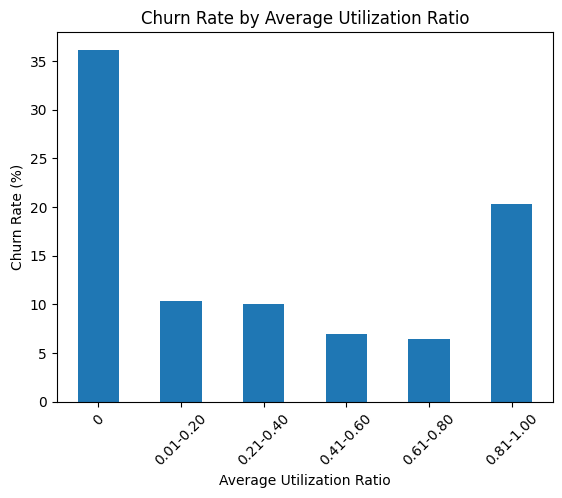

In [ ]:
# Churn rate by utilization group

utilization_group_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Average Utilization Ratio")
plt.xlabel("Average Utilization Ratio")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

#### 8.5.3 Total Revolving Balance vs Churn

In [ ]:
# Revolving balance statistics by customer status

revolving_balance_churn = df.groupby("Attrition_Flag")["Total_Revolving_Bal"].describe()

print(revolving_balance_churn)

                    count         mean         std  min    25%     50%  \
Attrition_Flag                                                           
Attrited Customer  1627.0   672.822987  921.385582  0.0    0.0     0.0   
Existing Customer  8500.0  1256.604118  757.745354  0.0  800.0  1364.0   

                      75%     max  
Attrition_Flag                     
Attrited Customer  1303.5  2517.0  
Existing Customer  1807.0  2517.0  


#### Comment

Attrited customers have substantially lower revolving balances than existing customers. Their average revolving balance is approximately 673 compared with 1,257 for existing customers, while the median balance is 0 for attrited customers compared with 1,364 for existing customers. This suggests that lower revolving balances are associated with customer churn and may reflect lower engagement with the bank's credit products.

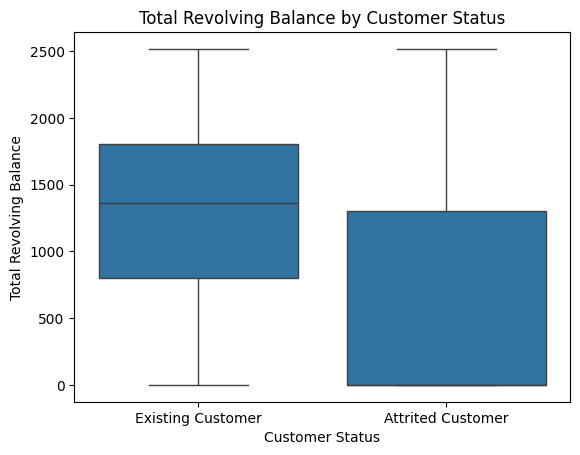

In [ ]:
# Revolving balance by customer status

sns.boxplot(
    data=df,
    x="Attrition_Flag",
    y="Total_Revolving_Bal")

plt.title("Total Revolving Balance by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Total Revolving Balance")

plt.show()

#### 8.5.4 Average Open to Buy vs Churn

In [ ]:
# Average open to buy statistics by customer status

open_to_buy_churn = df.groupby("Attrition_Flag")["Avg_Open_To_Buy"].describe()

print(open_to_buy_churn)

                    count         mean          std   min     25%     50%  \
Attrition_Flag                                                              
Attrited Customer  1627.0  7463.216472  9109.208129   3.0  1587.0  3488.0   
Existing Customer  8500.0  7470.273400  9087.671862  15.0  1184.5  3469.5   

                       75%      max  
Attrition_Flag                       
Attrited Customer  9257.50  34516.0  
Existing Customer  9978.25  34516.0  


#### Comment

Average Open to Buy is very similar between attrited and existing customers. Attrited customers have an average of approximately 7,463 compared with 7,470 for existing customers, while their median values are also nearly identical. This suggests that Average Open to Buy alone does not appear to be a strong differentiator of customer churn.

### 8.6 Changes in Customer Activity

#### 8.6.1 Transaction Amount Change vs Churn

In [ ]:
# Transaction amount change statistics by customer status

amount_change_churn = df.groupby("Attrition_Flag")["Total_Amt_Chng_Q4_Q1"].describe()

print(amount_change_churn)

                    count      mean       std    min     25%    50%    75%  \
Attrition_Flag                                                               
Attrited Customer  1627.0  0.694277  0.214924  0.000  0.5445  0.701  0.856   
Existing Customer  8500.0  0.772510  0.217783  0.256  0.6430  0.743  0.860   

                     max  
Attrition_Flag            
Attrited Customer  1.492  
Existing Customer  3.397  


#### Comment

Attrited customers have a lower average transaction amount change ratio of approximately 0.694 compared with 0.773 for existing customers. Their median ratios are also lower at 0.701 and 0.743 respectively. This suggests that attrited customers tend to show a somewhat greater decline in transaction amount between Q1 and Q4, although the difference between the two groups is moderate.

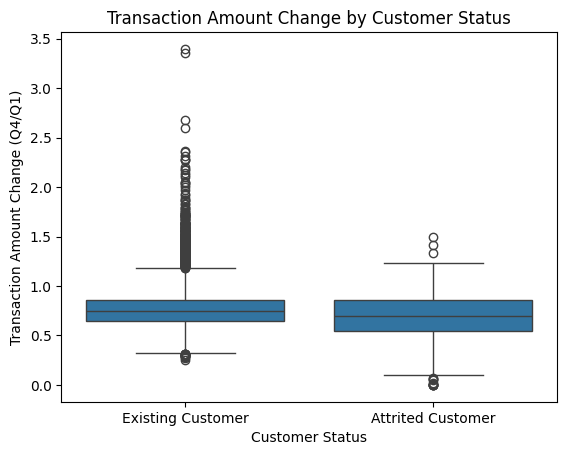

In [ ]:
# Transaction amount change by customer status

sns.boxplot(
    data=df,
    x="Attrition_Flag",
    y="Total_Amt_Chng_Q4_Q1")

plt.title("Transaction Amount Change by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Transaction Amount Change (Q4/Q1)")

plt.show()

#### 8.6.2 Transaction Count Change vs Churn

In [ ]:
# Transaction count change statistics by customer status

count_change_churn = df.groupby("Attrition_Flag")["Total_Ct_Chng_Q4_Q1"].describe()

print(count_change_churn)

                    count      mean       std    min    25%    50%    75%  \
Attrition_Flag                                                              
Attrited Customer  1627.0  0.554386  0.226854  0.000  0.400  0.531  0.692   
Existing Customer  8500.0  0.742434  0.228054  0.028  0.617  0.721  0.833   

                     max  
Attrition_Flag            
Attrited Customer  2.500  
Existing Customer  3.714  


#### Comment

Attrited customers have a lower average transaction count change ratio of approximately 0.554 compared with 0.742 for existing customers. Their median ratios are also lower at 0.531 and 0.721 respectively. This suggests that lower transaction count change is associated with customer churn and may indicate declining customer activity.

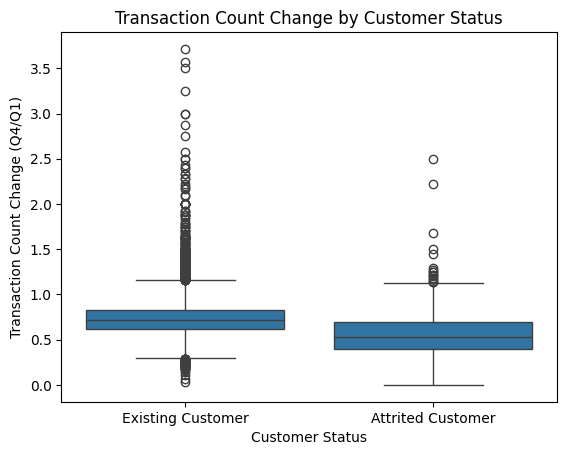

In [ ]:
# Transaction count change by customer status

sns.boxplot(
    data=df,
    x="Attrition_Flag",
    y="Total_Ct_Chng_Q4_Q1")

plt.title("Transaction Count Change by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Transaction Count Change (Q4/Q1)")

plt.show()

### 8.7 Remaining Variable Analysis

#### 8.7.1 Dependent Count vs Churn

In [ ]:
# Dependent count distribution - count and percentage

print("Dependent Count:")
print(df["Dependent_count"].value_counts().sort_index())

print()

print("Dependent Count Percentage:")
print(df["Dependent_count"].value_counts(normalize=True).sort_index() * 100)

Dependent Count:
Dependent_count
0     904
1    1838
2    2655
3    2732
4    1574
5     424
Name: count, dtype: int64

Dependent Count Percentage:
Dependent_count
0     8.926632
1    18.149501
2    26.217044
3    26.977387
4    15.542609
5     4.186827
Name: proportion, dtype: float64


#### Comment

Most customers have 2 or 3 dependents, representing approximately 26.22% and 26.98% of customers respectively. Customers with 5 dependents form the smallest group at approximately 4.19%.

In [ ]:
# Churn rate within each dependent count

dependent_churn = pd.crosstab(
    df["Dependent_count"],
    df["Attrition_Flag"],
    normalize="index") * 100

print(dependent_churn)

Attrition_Flag   Attrited Customer  Existing Customer
Dependent_count                                      
0                        14.933628          85.066372
1                        14.635473          85.364527
2                        15.706215          84.293785
3                        17.642753          82.357247
4                        16.518424          83.481576
5                        15.094340          84.905660


#### Comment

Churn rates are relatively similar across dependent count groups, ranging from approximately 14.64% to 17.64%. Customers with 3 dependents have the highest churn rate at approximately 17.64%, but the differences between groups are relatively small. This suggests that dependent count alone is unlikely to be a strong churn indicator.

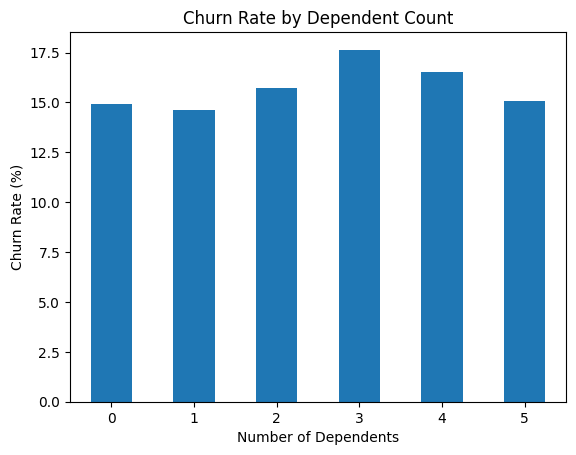

In [ ]:
# Churn rate by dependent count

dependent_churn["Attrited Customer"].plot(kind="bar")

plt.title("Churn Rate by Dependent Count")
plt.xlabel("Number of Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 9. Key Churn Findings & Business Insights

### 9.1 Strong Churn Indicators

#### Total Transaction Count

Transaction activity showed one of the strongest relationships with customer churn. Customers making 31–50 transactions had a churn rate of approximately 40.45%, while churn declined sharply among customers with higher transaction activity. Customers making 71–90 transactions had a churn rate of only 3.28%, and customers making more than 90 transactions had churn rates below 1%.

This suggests that low transaction activity is an important indicator of customer churn.

#### Customer Contact Count

Churn increased substantially as the number of customer contacts with the bank increased. Customers with no contacts had a churn rate of approximately 1.75%, compared with 20.15% for customers with 3 contacts and 33.52% for customers with 5 contacts. Customers with 6 contacts showed 100% churn, although this group contained only 54 customers.

This suggests that frequent customer contact may be an important warning signal for potential churn.

#### Total Relationship Count

Customers with fewer banking relationships showed considerably higher churn. Customers with 1 or 2 relationships had churn rates of approximately 25.60% and 27.84% respectively, compared with only 10.50% among customers with 6 relationships.

This suggests that customers with deeper relationships with the bank are generally less likely to churn.

#### Average Utilization Ratio

Credit utilization showed a strong relationship with churn. Customers with zero utilization had a churn rate of approximately 36.15%, while customers with moderate utilization between 0.41 and 0.80 had churn rates of approximately 6–7%. Churn increased again to approximately 20.34% among customers with utilization above 0.80.

This suggests that both zero utilization and very high utilization may be associated with increased churn risk.

#### Total Revolving Balance

Attrited customers had substantially lower revolving balances than existing customers. Their average revolving balance was approximately 673 compared with 1,257 for existing customers. The median revolving balance was 0 for attrited customers compared with 1,364 for existing customers.

This suggests that lower revolving balances are associated with customer churn and may reflect lower engagement with the bank's credit products.

#### Transaction Count Change

Attrited customers had a lower average transaction count change ratio of approximately 0.554 compared with 0.742 for existing customers. Their median ratios were also lower at 0.531 and 0.721 respectively.

This suggests that declining transaction activity over time may provide an additional warning signal for customer churn.

#### Months Inactive

Churn generally increased as customer inactivity increased from 1 to 4 months. The churn rate increased from approximately 4.48% for customers inactive for 1 month to 29.89% for customers inactive for 4 months. However, this pattern did not continue for customers inactive for 5 or 6 months, and the 0-month group had a very small sample size.

This suggests that increasing inactivity may be associated with higher churn, although the relationship is not consistent across all inactivity levels.

### 9.2 Moderate / Mixed Churn Indicators

#### Total Transaction Amount

Attrited customers had a lower average total transaction amount of approximately 3,095 compared with 4,655 for existing customers. Their median transaction amounts were also lower at 2,329 and 4,100 respectively.

However, churn rates across transaction amount groups were not consistent. For example, customers in the 8,001–10,000 group had a relatively high churn rate of approximately 43.20%, while customers in the 10,001+ group had a churn rate of only 1.32%.

This suggests that transaction amount is associated with churn, but the relationship is non-linear and less straightforward than transaction count.

#### Transaction Amount Change

Attrited customers had a lower average transaction amount change ratio of approximately 0.694 compared with 0.773 for existing customers. Their median ratios were also slightly lower at 0.701 and 0.743 respectively.

Although this indicates some difference in transaction amount changes between the two customer groups, the distributions showed considerable overlap. Therefore, transaction amount change appears to have a moderate rather than strong relationship with churn.

#### Card Category

Churn varied across card categories. Platinum customers had the highest churn rate at 25.00%, followed by Gold customers at approximately 18.10%, Blue customers at 16.10%, and Silver customers at 14.77%.

However, the dataset is heavily dominated by Blue card customers, while there are only 20 Platinum customers and 116 Gold customers. Therefore, the higher churn rates among these smaller categories should be interpreted cautiously.

### 9.3 Weak Churn Indicators

#### Customer Age

Customer age showed little difference between attrited and existing customers. Their average ages were approximately 46.66 and 46.26 years respectively. Churn rates were also relatively similar across the main age groups, suggesting that age alone is not a strong churn indicator.

#### Gender

Female customers had a slightly higher churn rate of approximately 17.36% compared with 14.62% for male customers. Although some difference exists, gender appears to be a relatively weak churn indicator compared with customer activity and engagement variables.

#### Education Level

Churn rates were relatively similar across most education levels, generally ranging between 15% and 17%. Doctorate customers showed a higher churn rate of approximately 21.06%, but this group contained only 451 customers. Overall, education level does not appear to be a strong standalone churn indicator.

#### Marital Status

Churn rates varied only slightly across marital status groups, ranging from approximately 15.13% for married customers to 17.22% for customers with unknown marital status. This relatively narrow range suggests that marital status is not a strong churn indicator.

#### Income Category

Churn rates were relatively similar across income categories. Customers earning \$120K or more had the highest churn rate at approximately 17.33%, while customers earning \$60K–\$80K had the lowest at approximately 13.48%. Overall, income category showed only a modest relationship with churn.

#### Dependent Count

Churn rates across dependent count groups ranged from approximately 14.64% to 17.64%. The relatively small differences between groups suggest that the number of dependents is unlikely to be a strong churn indicator.

#### Months on Book

Customer tenure showed almost no difference between attrited and existing customers. Their average months on book were approximately 36.18 and 35.88 months respectively, while both groups had a median of 36 months. This suggests that customer tenure alone is not strongly associated with churn.

#### Credit Limit

Attrited customers had a slightly lower average credit limit of approximately 8,136 compared with 8,727 for existing customers. However, the distributions showed considerable overlap, suggesting that credit limit alone is not a strong churn differentiator.

#### Average Open to Buy

Average Open to Buy was almost identical between attrited and existing customers, with average values of approximately 7,463 and 7,470 respectively. This suggests that Average Open to Buy alone provides little differentiation between customers who churn and those who remain.

### 9.4 Overall Business Insights

#### 1. Customer Behaviour Shows Stronger Churn Patterns Than Demographics

The analysis suggests that customer behaviour and engagement variables are more strongly associated with churn than demographic characteristics. Variables such as transaction count, customer contact frequency, relationship count, inactivity, utilization ratio, and revolving balance showed clearer differences between attrited and existing customers. In comparison, age, gender, education, marital status, income, and dependent count showed relatively small differences in churn.

#### 2. Lower Transaction Activity Is Associated With Higher Churn

Customers with lower transaction activity showed substantially higher churn. Customers making 31–50 transactions had a churn rate of approximately 40.45%, while churn fell to 3.28% among customers making 71–90 transactions and below 1% among customers making more than 90 transactions. Attrited customers also showed a lower transaction count change ratio than existing customers.

This indicates that lower or declining transaction activity may be an important early warning signal for customer churn.

#### 3. Frequent Customer Contact May Signal Churn Risk

Churn increased substantially with customer contact frequency. Customers with 3 contacts had a churn rate of approximately 20.15%, increasing to 33.52% among customers with 5 contacts. Although the 6-contact group was small, all 54 customers in this group had churned.

Frequent contact may therefore indicate unresolved service issues, dissatisfaction, or other customer concerns and could be used as a warning signal for potential churn.

#### 4. Stronger Customer Relationships Are Associated With Lower Churn

Customers with fewer banking relationships showed considerably higher churn. Customers with 1 or 2 relationships had churn rates of approximately 25.60% and 27.84%, compared with only 10.50% among customers with 6 relationships.

This suggests that customers with deeper relationships and greater engagement with the bank are generally less likely to churn.

#### 5. Credit Usage Patterns May Help Identify At-Risk Customers

Customers with zero credit utilization had a churn rate of approximately 36.15%, while moderate utilization levels were associated with considerably lower churn. Attrited customers also had a median revolving balance of zero compared with 1,364 for existing customers.

These findings suggest that customers who make little use of their available credit may be less engaged with the bank. However, very high utilization was also associated with increased churn, indicating that the relationship between credit usage and churn is not completely linear.

### 9.5 Business Recommendations

#### 1. Develop an Early Churn Warning System

The bank should develop an early warning system to identify customers showing behavioural signs associated with churn. Key indicators could include lower transaction counts, declining transaction activity, increasing inactivity, frequent customer contacts, fewer banking relationships, and unusual credit utilization patterns.

Customers displaying several of these warning signals could be identified for proactive retention efforts before they leave the bank.

#### 2. Monitor Declining Transaction Activity

The bank should monitor customers whose transaction activity is low or declining. Customers making 31–50 transactions showed particularly high churn in this dataset, while customers with higher transaction activity generally had much lower churn rates.

Customers showing a sustained decline in transaction activity could be targeted with personalized offers, rewards, or engagement campaigns designed to encourage continued card usage.

#### 3. Prioritize Customers with Frequent Bank Contacts

Customers who contact the bank frequently should receive additional attention, as churn increased substantially with contact frequency in this dataset. The bank could identify customers making repeated contacts and review whether their issues have been successfully resolved.

Follow-up communication after repeated service interactions may help identify unresolved problems and improve customer satisfaction before customers decide to leave.

#### 4. Strengthen Customer Relationships

Customers with fewer banking relationships showed considerably higher churn than customers with multiple relationships. The bank could encourage suitable customers to use additional relevant products or services, such as savings accounts, payment services, or other banking products.

Increasing meaningful customer engagement across multiple services may help strengthen the overall customer relationship and support retention.

#### 5. Re-engage Inactive Customers

The bank should monitor customers experiencing increasing periods of inactivity. Churn increased considerably as inactivity rose from 1 to 4 months in this dataset.

Customers showing increasing inactivity could receive targeted re-engagement campaigns, personalized rewards, or relevant product reminders before disengagement becomes more severe.

#### 6. Monitor Credit Engagement Patterns

Credit utilization could provide an additional signal for identifying potentially at-risk customers. Customers with zero utilization showed relatively high churn, while churn also increased among customers with very high utilization.

The bank could monitor unusual utilization patterns and combine this information with other behavioural indicators rather than using credit utilization alone to identify churn risk.

#### 7. Focus Retention Strategies on Customer Behaviour

Demographic characteristics such as age, education, marital status, income, and dependent count showed relatively weak differences in churn compared with behavioural variables.

Therefore, retention strategies should focus primarily on changes in customer behaviour and engagement rather than relying heavily on demographic characteristics to identify potentially at-risk customers.

## 10. Export Cleaned Dataset

In [ ]:
# Create cleaned dataset

cleaned_df = df.drop(columns=[
    "Age_Group",
    "Transaction_Count_Group",
    "Transaction_Amount_Group",
    "Utilization_Group"])

# Save cleaned dataset as CSV

cleaned_df.to_csv("Bank_Churn_Cleaned.csv", index=False)


print("Final Dataset Shape:", cleaned_df.shape)



Final Dataset Shape: (10127, 21)


In [ ]:
# Download cleaned dataset

from google.colab import files
files.download("Bank_Churn_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>